![CCAI 9012 course banner](../../../docs/figs/brand_identity/banner.png)

# Week 9: Tokenisation — what an LLM receives before it predicts

A language model does not receive a sentence as a list of dictionary words. Its tokenizer turns text into **token pieces**, then converts each piece to a numeric **vocabulary ID**. The model works with that ordered ID sequence. Seeing the pieces makes the next lesson on token probabilities easier to understand: the model predicts a next **token**, which may be a word, word part, punctuation mark, or space-bearing piece.

## What you will learn

By the end, you should be able to distinguish words, tokens, and IDs; inspect how spaces, punctuation, and less common forms affect token boundaries; encode and decode a sentence; and explain why token count differs from word count.

## Roadmap

| Step | Input | What you inspect | Output |
| --- | --- | --- | --- |
| 1 | Short phrases | Visible token pieces | Tokens and IDs |
| 2 | Controlled text changes | Spaces, punctuation, capitalisation | Changed boundaries |
| 3 | Common and unusual forms | Subword trade-off | More or fewer pieces |
| 4 | One complete sentence | Encode and decode | Recovered text |
| 5 | Several sentences | Word count versus token count | Comparison chart |
| 6 | One new sentence | Character spans and your own example | A documented prediction |

<p align="center"><img src="../figs/tokenisation_pipeline.svg" alt="Text becomes model-specific token pieces, vocabulary IDs, and a model input sequence" width="100%"><br><em>Figure 1. The saved GPT-2 example splits Hello, world! into four pieces and four IDs.</em></p>

**Before you begin:** The notebook uses the GPT-2 tokenizer through `transformers`. The first load may download tokenizer files into the course model cache; it does **not** download GPT-2 model weights or generate text. No API key is needed. The examples and exact IDs apply to this tokenizer; another model may divide the same text differently.


In [21]:
from transformers import AutoTokenizer
from ccai9012.paths import MODELS_DIR

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=str(MODELS_DIR))


## Step 1 — See text become pieces and IDs

Run the examples below. For each sentence, compare the raw text, the readable token pieces, and the integer IDs. Predict whether `Hello, world!` will be three tokens just because it contains two written words. Count what the tokenizer actually returns.

GPT-2 often displays a leading space as `Ġ` attached to the following piece. This is a **display convention for its byte-level tokenizer**, not a character you need to type in the source sentence.


In [23]:
examples = ["cat", "unbelievable", "The capital of France is", "Hello, world!"]
for text in examples:
    pieces = tokenizer.tokenize(text)
    ids = tokenizer.encode(text, add_special_tokens=False)
    print(f"{text!r} -> {pieces} -> {ids}")

'cat' -> ['cat'] -> [9246]
'unbelievable' -> ['un', 'bel', 'iev', 'able'] -> [403, 6667, 11203, 540]
'The capital of France is' -> ['The', 'Ġcapital', 'Ġof', 'ĠFrance', 'Ġis'] -> [464, 3139, 286, 4881, 318]
'Hello, world!' -> ['Hello', ',', 'Ġworld', '!'] -> [15496, 11, 995, 0]


### Read the first output

Which example produced a piece that was not a whole word? Which punctuation mark became a separate piece? Compare `tokenizer.tokenize(text)` with `tokenizer.encode(text, add_special_tokens=False)`: the lists have corresponding positions, but the second list contains IDs the model can use. Token IDs are identifiers, not scores or probabilities.


## Step 2 — Change one visible detail at a time

Spaces, punctuation, and capital letters can affect token boundaries. The four examples below keep most of a phrase fixed. Before running, predict whether adding a second space or changing `Hello` to `hello` will preserve every token ID. Use `repr()` so leading spaces are visible in the printed output.


In [25]:
space_examples = [
    "Hello world",
    "Hello  world",
    "hello world",
    "Hello, world!",
]
for text in space_examples:
    pieces = tokenizer.tokenize(text)
    print(f"{text!r:20} -> {pieces!r} ({len(pieces)} tokens)")


'Hello world'        -> ['Hello', 'Ġworld'] (2 tokens)
'Hello  world'       -> ['Hello', 'Ġ', 'Ġworld'] (3 tokens)
'hello world'        -> ['hello', 'Ġworld'] (2 tokens)
'Hello, world!'      -> ['Hello', ',', 'Ġworld', '!'] (4 tokens)


### Explain the difference

Find the token that marks a leading space. Did the double space change the output? Which comparison isolates capitalisation, and which also changes punctuation? Do not infer a general rule from one phrase: record the behaviour of **this** tokenizer on these inputs.


## Step 3 — Why subwords are useful

A tokenizer that memorises only whole words needs a very large vocabulary or an unknown-word fallback. Splitting every character keeps the vocabulary small but can create long sequences. Subword tokenizers combine reusable pieces. GPT-2 uses **byte-level byte-pair encoding (BPE)**: its vocabulary and learned merge rules determine which byte sequences are grouped into tokens. Figure 2 shows the actual pieces printed for `unbelievable` in Step 1. It is not a claim that GPT-2 always splits at meaningful morphemes.

<p align="center"><img src="../figs/subword_tradeoff.svg" alt="One word shown as a whole, twelve characters, and the four GPT-2 pieces un, bel, iev, and able" width="100%"><br><em>Figure 2. GPT-2 splits this word into four pieces; another tokenizer may split it differently.</em></p>

Predict which of these forms may take more pieces, then inspect the actual result. A familiar word need not be a single token, and an unfamiliar form need not be split at a linguistic root.


In [27]:
forms = ["walk", "walking", "replaying", "unbelievable", "CCAI9012"]
for form in forms:
    pieces = tokenizer.tokenize(form)
    print(f"{form:15} -> {pieces!r:45} count={len(pieces)}")

walk            -> ['walk']                                      count=1
walking         -> ['walking']                                   count=1
replaying       -> ['re', 'playing']                             count=2
unbelievable    -> ['un', 'bel', 'iev', 'able']                  count=4
CCAI9012        -> ['CC', 'AI', '9', '012']                      count=4


### Read the subword output

Pick two related forms. Which pieces are reused, and which differ? If `unbelievable` is split, resist calling every piece a prefix or suffix: tokenizer boundaries are learned from training text and need not match a grammar lesson. The next examples use the same tokenizer throughout so the comparison stays meaningful.


## Step 4 — Encode, then decode

`encode()` maps text to IDs; `convert_ids_to_tokens()` gives readable piece labels; `decode()` maps the IDs back to text. Run the round trip and inspect each row. We pass `add_special_tokens=False` to focus on the sentence itself. Special-token behaviour is model-specific and belongs to the model's full input format.


In [29]:
sentence = "Hello, world!"
ids = tokenizer.encode(sentence, add_special_tokens=False)
pieces = tokenizer.convert_ids_to_tokens(ids)
for position, (piece, token_id) in enumerate(zip(pieces, ids)):
    print(f"position {position}: piece={piece!r:15} id={token_id}")
recovered = tokenizer.decode(ids)
print("Original: ", repr(sentence))
print("Decoded:  ", repr(recovered))

position 0: piece='Hello'         id=15496
position 1: piece=','             id=11
position 2: piece='Ġworld'        id=995
position 3: piece='!'             id=0
Original:  'Hello, world!'
Decoded:   'Hello, world!'


### Check the round trip

Did the decoded string match the original text, including the comma and space? If the readable token pieces look odd, compare the **decoded sentence** before deciding that text was lost. The piece labels are a human-readable view of an internal vocabulary, not a promise that every label is a standalone word.


## Step 5 — Count words and tokens separately

A word count based on spaces is convenient but is not a token count. The following chart compares both measures for a few sentences. It is a small demonstration with GPT-2, not a universal conversion rule for another language, tokenizer, or billing system.

**Pause and predict:** Which sentence might have the largest gap between its whitespace-separated word count and token count? Explain your prediction before viewing the chart.


Example 1: 'The capital of France is Paris.' -> whitespace groups=6, GPT-2 tokens=7
Example 2: 'Hello, world!' -> whitespace groups=2, GPT-2 tokens=4
Example 3: 'A surprisingly long technical_identifier_2026 appears.' -> whitespace groups=5, GPT-2 tokens=12
Example 4: '城市需要更多树荫。' -> whitespace groups=1, GPT-2 tokens=21


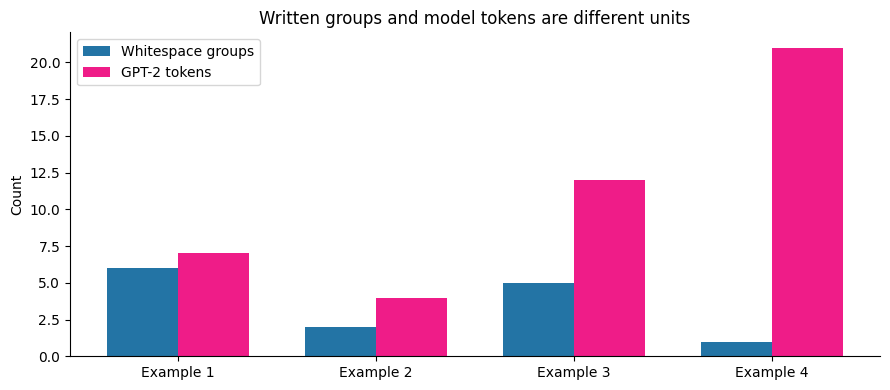

In [31]:
import matplotlib.pyplot as plt

count_examples = [
    "The capital of France is Paris.",
    "Hello, world!",
    "A surprisingly long technical_identifier_2026 appears.",
    "城市需要更多树荫。",
]
word_counts = [len(text.split()) for text in count_examples]
token_counts = [len(tokenizer.encode(text, add_special_tokens=False)) for text in count_examples]
labels = [f"Example {i}" for i in range(1, len(count_examples) + 1)]
for label, text, words, tokens in zip(labels, count_examples, word_counts, token_counts):
    print(f"{label}: {text!r} -> whitespace groups={words}, GPT-2 tokens={tokens}")

positions = list(range(len(labels)))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([x - 0.18 for x in positions], word_counts, width=0.36, label="Whitespace groups", color="#2374a5")
ax.bar([x + 0.18 for x in positions], token_counts, width=0.36, label="GPT-2 tokens", color="#ef1c88")
ax.set_xticks(positions, labels)
ax.set_ylabel("Count")
ax.set_title("Written groups and model tokens are different units")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Read the comparison chart

Which example has the largest difference? The Chinese sentence shows why `str.split()` is not a meaningful **word** count across languages: it counts whitespace groups, not Chinese words. Its token count is still valid for this GPT-2 tokenizer. A different tokenizer may yield another count. If a model has a context-window limit, count with the tokenizer paired with that model.


## Step 6 — Match tokens back to character spans

Fast tokenizers can report **offsets**: start and end character positions in the original string for each token. This helps trace a model input back to source text. The `Ġ` display marker may correspond to a leading space inside a returned span. Inspect both the piece label and the original slice.


In [33]:
trace_text = "Hello,  world!"
if tokenizer.is_fast:
    encoding = tokenizer(trace_text, add_special_tokens=False, return_offsets_mapping=True)
    trace_pieces = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
    for piece, (start, end) in zip(trace_pieces, encoding["offset_mapping"]):
        print(f"{piece!r:14} <- text[{start}:{end}] = {trace_text[start:end]!r}")
else:
    print("This tokenizer backend does not provide offset mappings; use a fast tokenizer for this step.")

'Hello'        <- text[0:5] = 'Hello'
','            <- text[5:6] = ','
'Ġ'            <- text[6:7] = ' '
'Ġworld'       <- text[7:13] = ' world'
'!'            <- text[13:14] = '!'


### Try one sentence of your own

Choose a short sentence with punctuation, a repeated space, a number, or a place name. Predict two token boundaries, then replace `student_text` below and compare the pieces. Finally decode the IDs. Write one sentence explaining a boundary that surprised you.


In [35]:
student_text = "A cooler street needs 3 more trees."
student_ids = tokenizer.encode(student_text, add_special_tokens=False)
print("Text:   ", repr(student_text))
print("Pieces: ", tokenizer.convert_ids_to_tokens(student_ids))
print("IDs:    ", student_ids)
print("Decoded:", repr(tokenizer.decode(student_ids)))

Text:    'A cooler street needs 3 more trees.'
Pieces:  ['A', 'Ġcooler', 'Ġstreet', 'Ġneeds', 'Ġ3', 'Ġmore', 'Ġtrees', '.']
IDs:     [32, 19346, 4675, 2476, 513, 517, 7150, 13]
Decoded: 'A cooler street needs 3 more trees.'


## What to take away

1. **Words and tokens are different units.** A piece may contain a full word, part of a word, punctuation, or a visible space marker.
2. **The tokenizer determines the IDs.** Always pair token counts and boundaries with the model/tokenizer actually used.
3. **Encoding is only the input step.** The model in [Next-Token Probabilities](week9_ic_llm_probability.ipynb) uses token IDs to score possible next tokens; this notebook does not measure those probabilities or verify factual answers.

**Extend the lesson:** Change `student_text`, compare a second tokenizer only after recording its name, or use offsets to highlight source spans in a document. **Limit:** The examples use GPT-2's byte-level BPE; their exact pieces and counts are not general rules for all models.

**Further reading (official):** [Hugging Face: Tokenizers](https://huggingface.co/docs/course/chapter2/4), [Normalization and pre-tokenization](https://huggingface.co/docs/course/chapter6/4), [Byte-Pair Encoding](https://huggingface.co/docs/course/chapter6/5), and the [Transformers tokenizer API](https://huggingface.co/docs/transformers/main_classes/tokenizer).
